In [1]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [2]:
from binning_process.compare import compare_methods

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# np.random.seed(42)
# N = 5_000

# # Giả lập dữ liệu credit: income có quan hệ nghịch với bad rate
# income   = np.random.lognormal(mean=10, sigma=0.8, size=N)
# bad_prob = 1 / (1 + np.exp((income - 22000) / 6000))
# bad      = (np.random.rand(N) < bad_prob).astype(int)

# income_s = pd.Series(income, name="income")
# income_s.iloc[:200] = np.nan   # 4% missing
# income_s.iloc[200:250] = -1    # special value
# y_s = pd.Series(bad)

# print(f"Dataset: N={N}, bad_rate={bad.mean():.2%}")
# print(f"Missing={income_s.isna().sum()}, Special(-1)={(income_s==-1).sum()}\n")

# # ── So sánh 5 methods ──────────────────────────────────────────────────
# result = compare_methods(
#     x=income_s, y=y_s,
#     feature_name="income",
#     max_bins=10,
#     special_values=[-1],
# )

# # ── Xem chi tiết 1 method ─────────────────────────────────────────────
# print("Chi tiết IsotonicBinner:")
# b1 = IsotonicBinner(feature_name="income", max_bins=10, special_values=[-1])
# b1.fit(income_s, y_s)
# print(b1.summary().to_string(index=False))
# print(f"\nCut-points: {[round(c,1) for c in b1.cuts_]}")
# print(f"Monotonic : {b1.is_monotonic()} | Direction: {b1.direction_}")

# print("\nChi tiết DecisionTreeBinner:")
# b3 = DecisionTreeBinner(feature_name="income", max_bins=10, special_values=[-1])
# b3.fit(income_s, y_s)
# print(b3.summary().to_string(index=False))

# # ── Transform sang WOE ────────────────────────────────────────────────
# woe_vals = b1.transform(income_s)
# print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# # ── Plot ──────────────────────────────────────────────────────────────
# fig1 = b1.plot()
# plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
# print("\nĐã lưu: plot_isotonic.png")
# plt.show()

In [5]:
data = pd.read_csv(r"D:\Data\f88_bscore_v4\data\Data_Sets_15\20251030_Train_Data_15.csv")
data

,FlagTarget_B4+@9M,customer_code,cutoff_date,CUTOFF_MONTH_WID,min_trans_in_3month,min_trans_in_6month,ltv_max_closedloandtl,collateral_amt_latest,n_paidontime_in_3month,dpd_mean_in_9month,province_code_latest
0,0,16104509,20240331,202403,3857000.0,1036.0,2.250000,290.0,4.0,0.0,01
1,0,16104509,20240430,202404,1999.0,1999.0,2.250000,290.0,4.0,0.0,01
2,0,16104509,20240831,202408,1258.0,1258.0,2.250000,280.0,4.0,0.0,01
3,0,16177982,20240430,202404,7181465.0,7181465.0,14.305750,440.0,4.0,0.0,01
4,1,16216573,20240229,202402,5439179.0,5439179.0,1.431174,330.0,3.0,0.0,01
...,...,...,...,...,...,...,...,...,...,...,...
44742,0,202158016817,20240229,202402,6031726.0,6031726.0,10.066043,410.0,3.0,0.0,25
44743,0,202158241464,20240731,202407,5604057.0,5604057.0,2.878788,260.0,3.0,0.0,31
44744,0,202159861057,20240430,202404,11083452.0,9913704.0,6.308122,320.0,3.0,1.7,79
44745,0,202162178813,20240630,202406,1324772.0,654943.0,21.000000,380.0,4.0,0.0,48


In [6]:
X = data.drop('FlagTarget_B4+@9M', axis = 1)
y = data['FlagTarget_B4+@9M']

In [13]:
y.value_counts(normalize=True)

FlagTarget_B4+@9M
0    0.957137
1    0.042863
Name: proportion, dtype: float64

In [8]:
X['min_trans_in_3month']

0         3857000.0
1            1999.0
2            1258.0
3         7181465.0
4         5439179.0
            ...    
44742     6031726.0
44743     5604057.0
44744    11083452.0
44745     1324772.0
44746     6000752.0
Name: min_trans_in_3month, Length: 44747, dtype: float64

In [9]:
feature_name = 'min_trans_in_6month'
val = X[feature_name]
max_bins = 5
n_init_bins = 50
max_depth = 3
result, methods = compare_methods(
    x=val, y=y,
    feature_name=feature_name,
    max_bins=max_bins,
    n_init_bins=n_init_bins,
    max_depth=max_depth,
    special_values=[-1],
)

# # ── Transform sang WOE ────────────────────────────────────────────────
# woe_vals = b1.transform(val)
# print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# # ── Plot ──────────────────────────────────────────────────────────────
# fig1 = b1.plot()
# plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
# print("\nĐã lưu: plot_isotonic.png")
# plt.show()


  SO SÁNH METHODS — Feature: [min_trans_in_6month]
           Method        Group     IV  n_bins Monotonic  Direction  IV_Rating
         ChiMerge   supervised 0.1684       3         ✓ descending Trung bình
QuantileMonotonic   supervised 0.1670       6         ✓ descending Trung bình
     DecisionTree   supervised 0.1662       4         ✓ descending Trung bình
             MDLP   supervised 0.1636       2         ✓ descending Trung bình
         Isotonic   supervised 0.1599       5         ✓ descending Trung bình
         Spearman   supervised 0.1535       5         ✓ descending Trung bình
      JenksBreaks unsupervised 0.1171       3         ✓ descending Trung bình
        KSOptimal   supervised 0.0791       3         ✓ descending        Yếu
       EqualWidth unsupervised 0.0573       3         ✓ descending        Yếu
          LogOdds   supervised 0.0000       1         ✓ descending    Vô dụng



In [10]:
result

,Method,Group,IV,n_bins,Monotonic,Direction,IV_Rating,Cuts
0,ChiMerge,supervised,0.1684,3,✓,descending,Trung bình,"[234577.0, 1578247.0]"
1,QuantileMonotonic,supervised,0.1670,6,✓,descending,Trung bình,"[1150.0, 1443.86, 234577.0, 819990.0, 1447687.98]"
2,DecisionTree,supervised,0.1662,4,✓,descending,Trung bình,"[1705.5, 262126.0, 706467.5]"
3,MDLP,supervised,0.1636,2,✓,descending,Trung bình,[262126.0]
4,Isotonic,supervised,0.1599,5,✓,descending,Trung bình,"[1282.0, 110841.0, 228989.0, 537950.0]"
5,Spearman,supervised,0.1535,5,✓,descending,Trung bình,"[686678.0, 819990.0, 1447687.98, 1786012.0]"
6,JenksBreaks,unsupervised,0.1171,3,✓,descending,Trung bình,"[1651230.0, 9549924.5]"
7,KSOptimal,supervised,0.0791,3,✓,descending,Yếu,"[1703.0, 3286.0]"
8,EqualWidth,unsupervised,0.0573,3,✓,descending,Yếu,"[3730876.0, 11192438.0]"
9,LogOdds,supervised,0.0000,1,✓,descending,Vô dụng,[]


Isotonic
               feature                    bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month           (-inf, 1282]     5932      394        5538   
1  min_trans_in_6month      (1282, 1.108e+05]    11120      685       10435   
2  min_trans_in_6month  (1.108e+05, 2.29e+05]      641       34         607   
3  min_trans_in_6month   (2.29e+05, 5.38e+05]     1760       75        1685   
4  min_trans_in_6month        (5.38e+05, inf]    22825      655       22170   
5  min_trans_in_6month                Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0664  0.4453  0.0342    0.1599  
1      0.0616  0.3648  0.0414    0.1599  
2      0.0530  0.2061  0.0007    0.1599  
3      0.0426 -0.0237  0.0000    0.1599  
4      0.0287 -0.4336  0.0836    0.1599  
5      0.0304 -0.3573  0.0060       NaN  


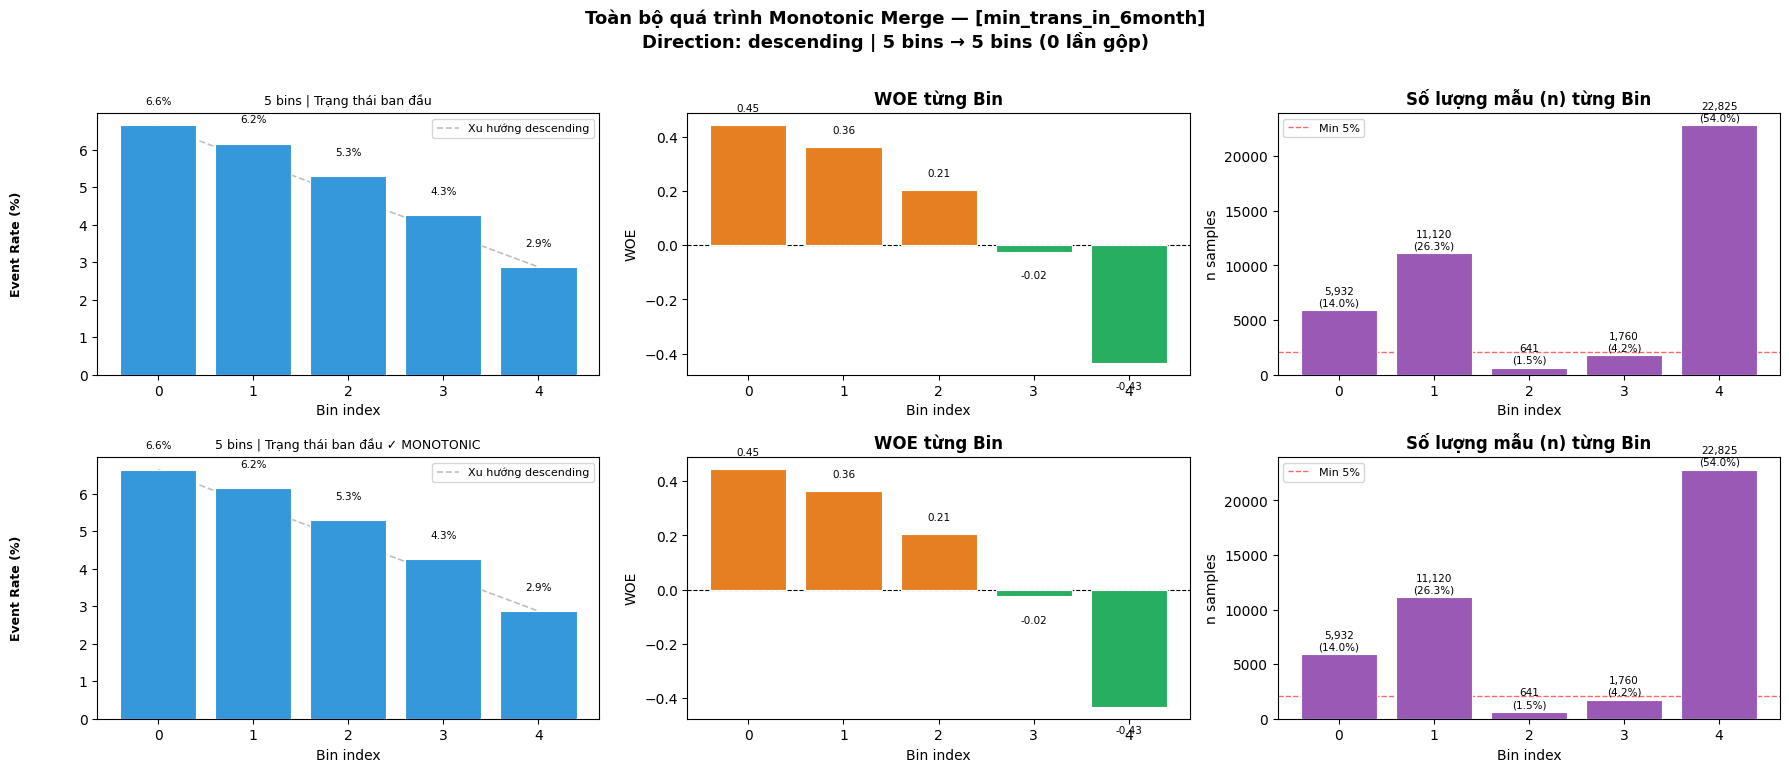

QuantileMonotonic
               feature                   bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month          (-inf, 1150]     4226      278        3948   
1  min_trans_in_6month          (1150, 1444]     3384      213        3171   
2  min_trans_in_6month     (1444, 2.346e+05]    10144      631        9513   
3  min_trans_in_6month  (2.346e+05, 8.2e+05]     3383      130        3253   
4  min_trans_in_6month  (8.2e+05, 1.448e+06]     3384      108        3276   
5  min_trans_in_6month      (1.448e+06, inf]    17757      483       17274   
6  min_trans_in_6month               Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0658  0.4350  0.0231     0.167  
1      0.0629  0.3878  0.0144     0.167  
2      0.0622  0.3752  0.0402     0.167  
3      0.0384 -0.1315  0.0013     0.167  
4      0.0319 -0.3239  0.0073     0.167  
5      0.0272 -0.4886  0.0807     0.167  
6      0.0304 -0.3573  0.0060       NaN  


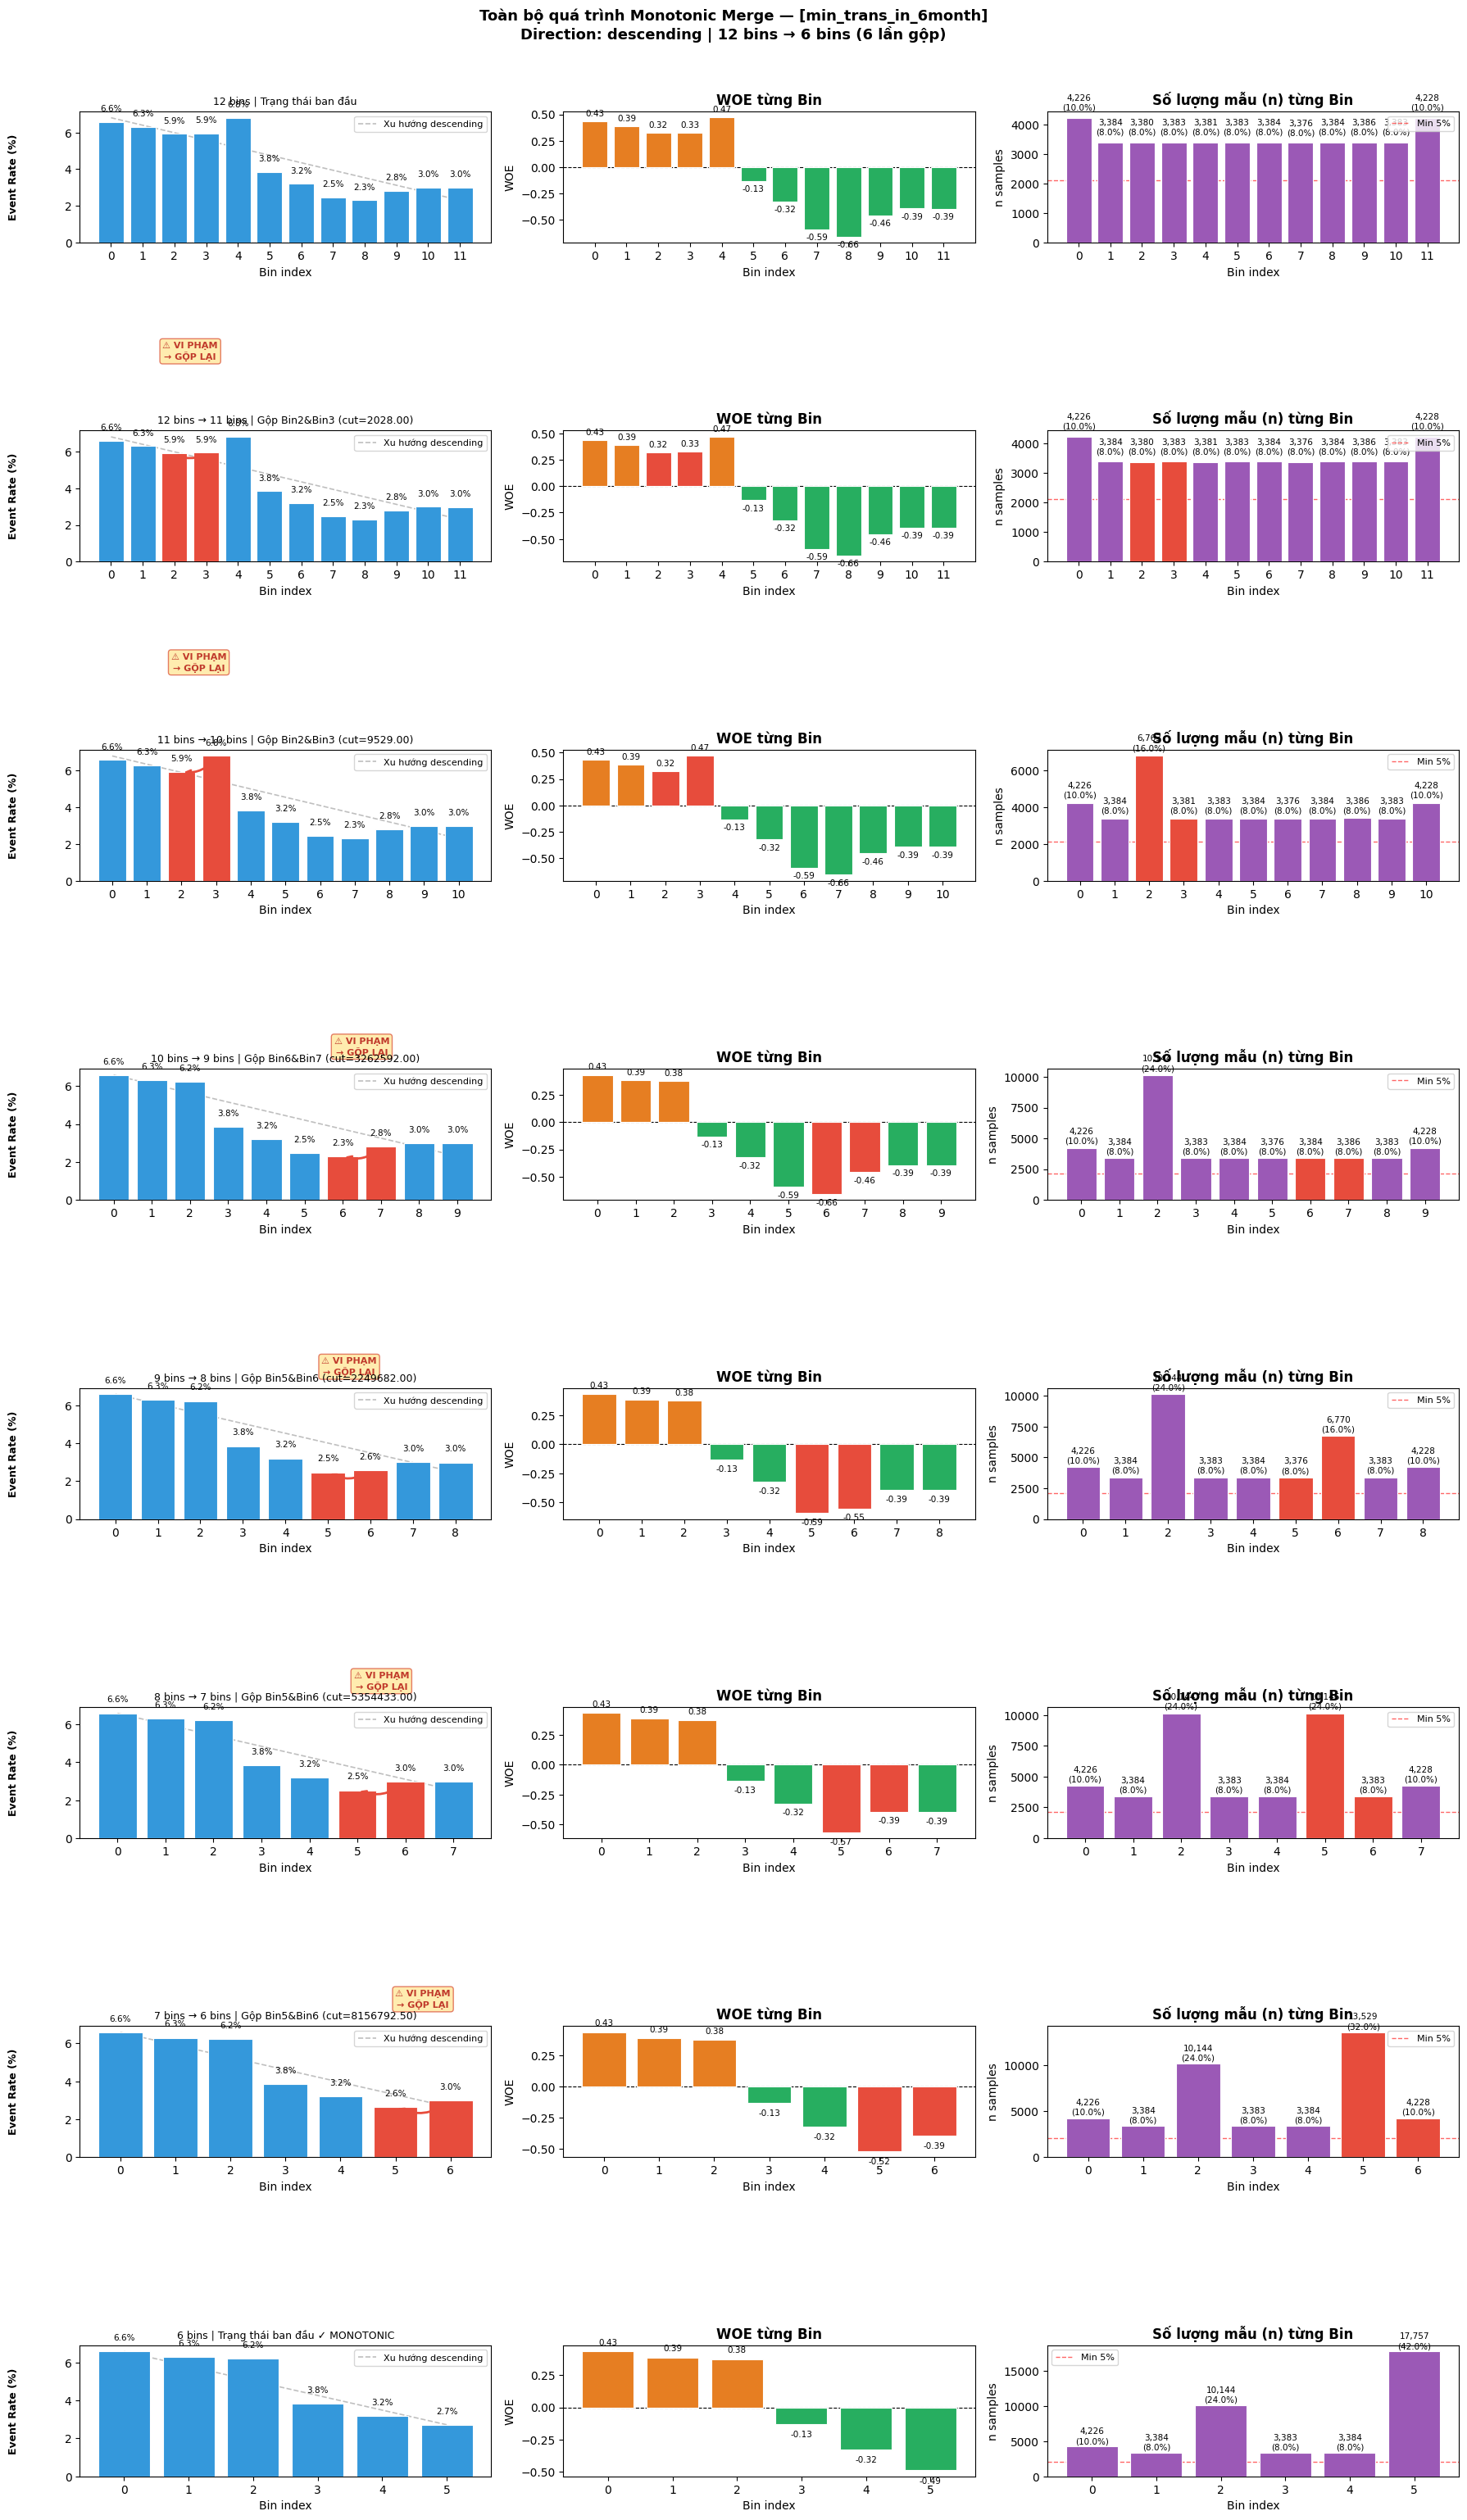

DecisionTree
               feature                     bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month            (-inf, 1706]     9540      625        8915   
1  min_trans_in_6month       (1706, 2.621e+05]     8355      509        7846   
2  min_trans_in_6month  (2.621e+05, 7.065e+05]     2541       87        2454   
3  min_trans_in_6month        (7.065e+05, inf]    21842      622       21220   
4  min_trans_in_6month                 Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0655  0.4306  0.0511    0.1662  
1      0.0609  0.3530  0.0290    0.1662  
2      0.0342 -0.2513  0.0034    0.1662  
3      0.0285 -0.4415  0.0827    0.1662  
4      0.0304 -0.3573  0.0060       NaN  


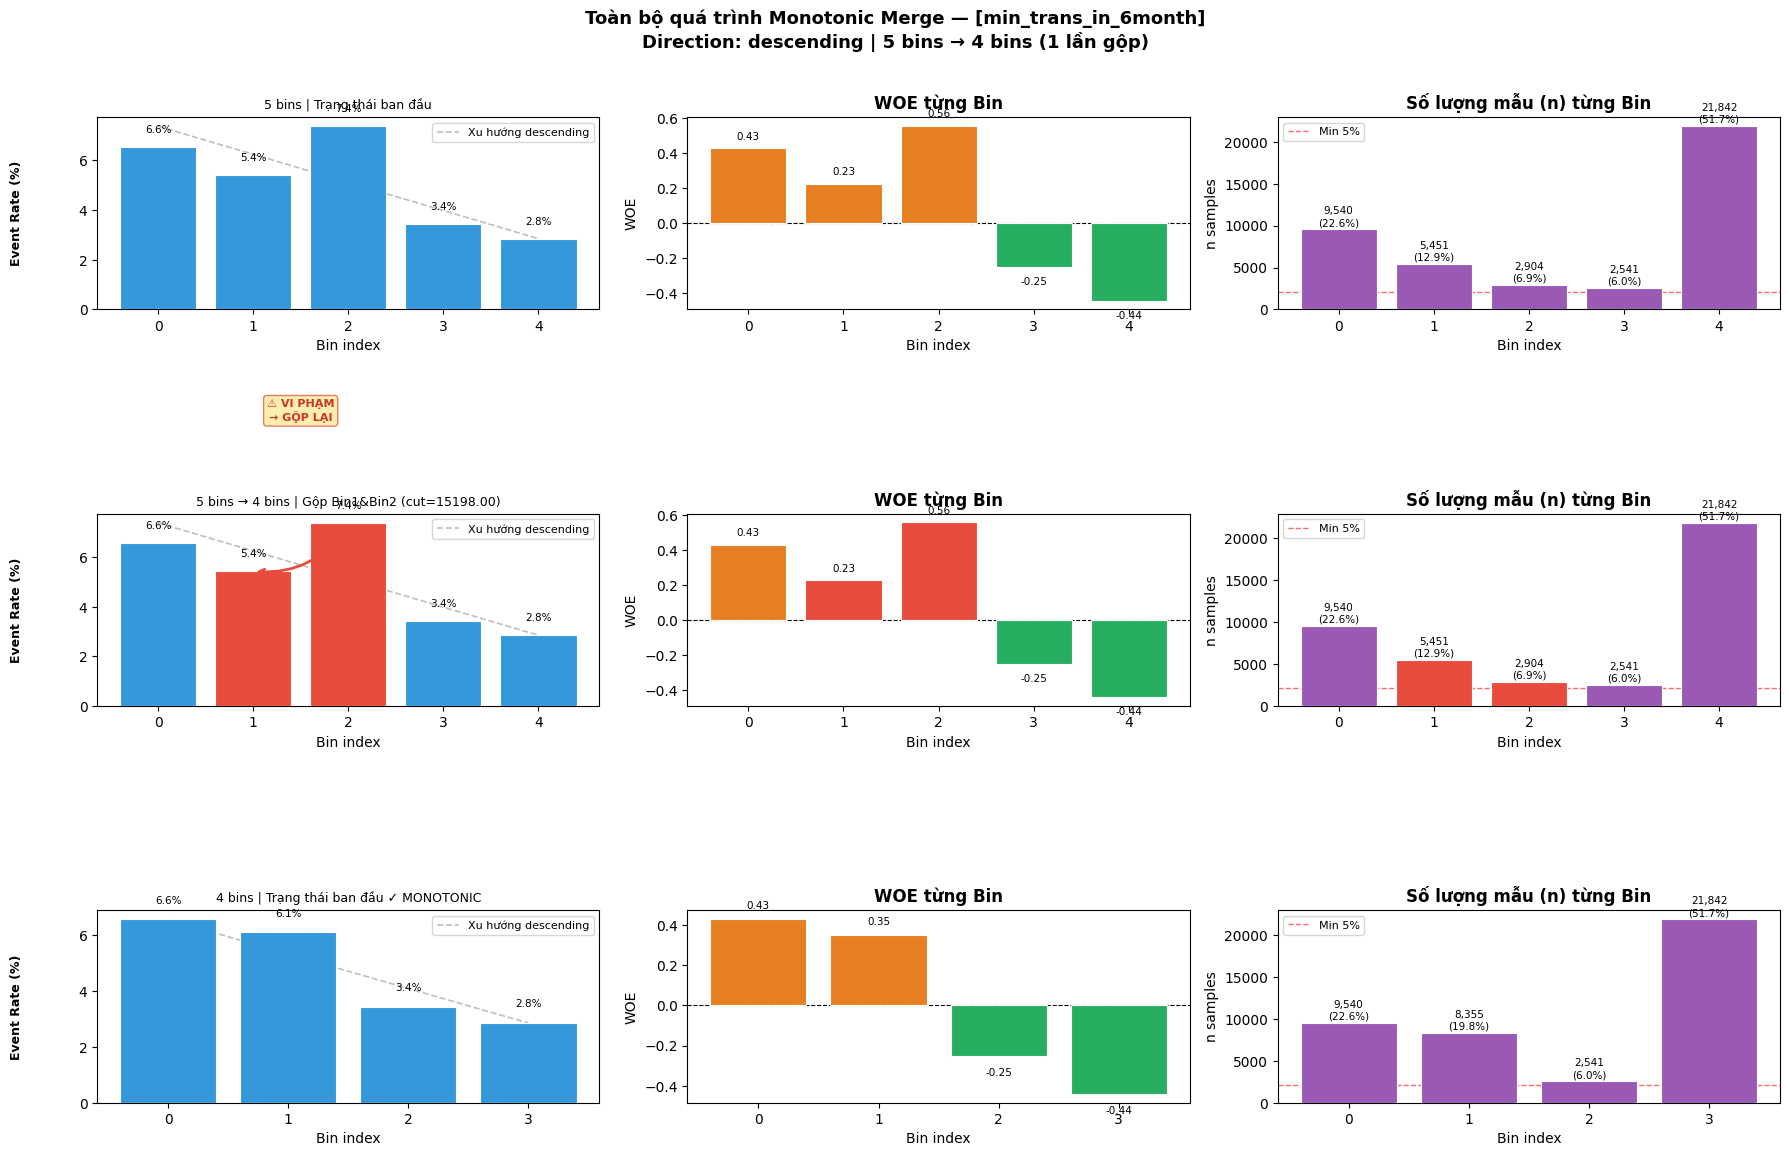

ChiMerge
               feature                     bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month       (-inf, 2.346e+05]    17754     1122       16632   
1  min_trans_in_6month  (2.346e+05, 1.578e+06]     7610      272        7338   
2  min_trans_in_6month        (1.578e+06, inf]    16914      449       16465   
3  min_trans_in_6month                 Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0632  0.3921  0.0774    0.1684  
1      0.0357 -0.2067  0.0070    0.1684  
2      0.0265 -0.5137  0.0840    0.1684  
3      0.0304 -0.3573  0.0060       NaN  


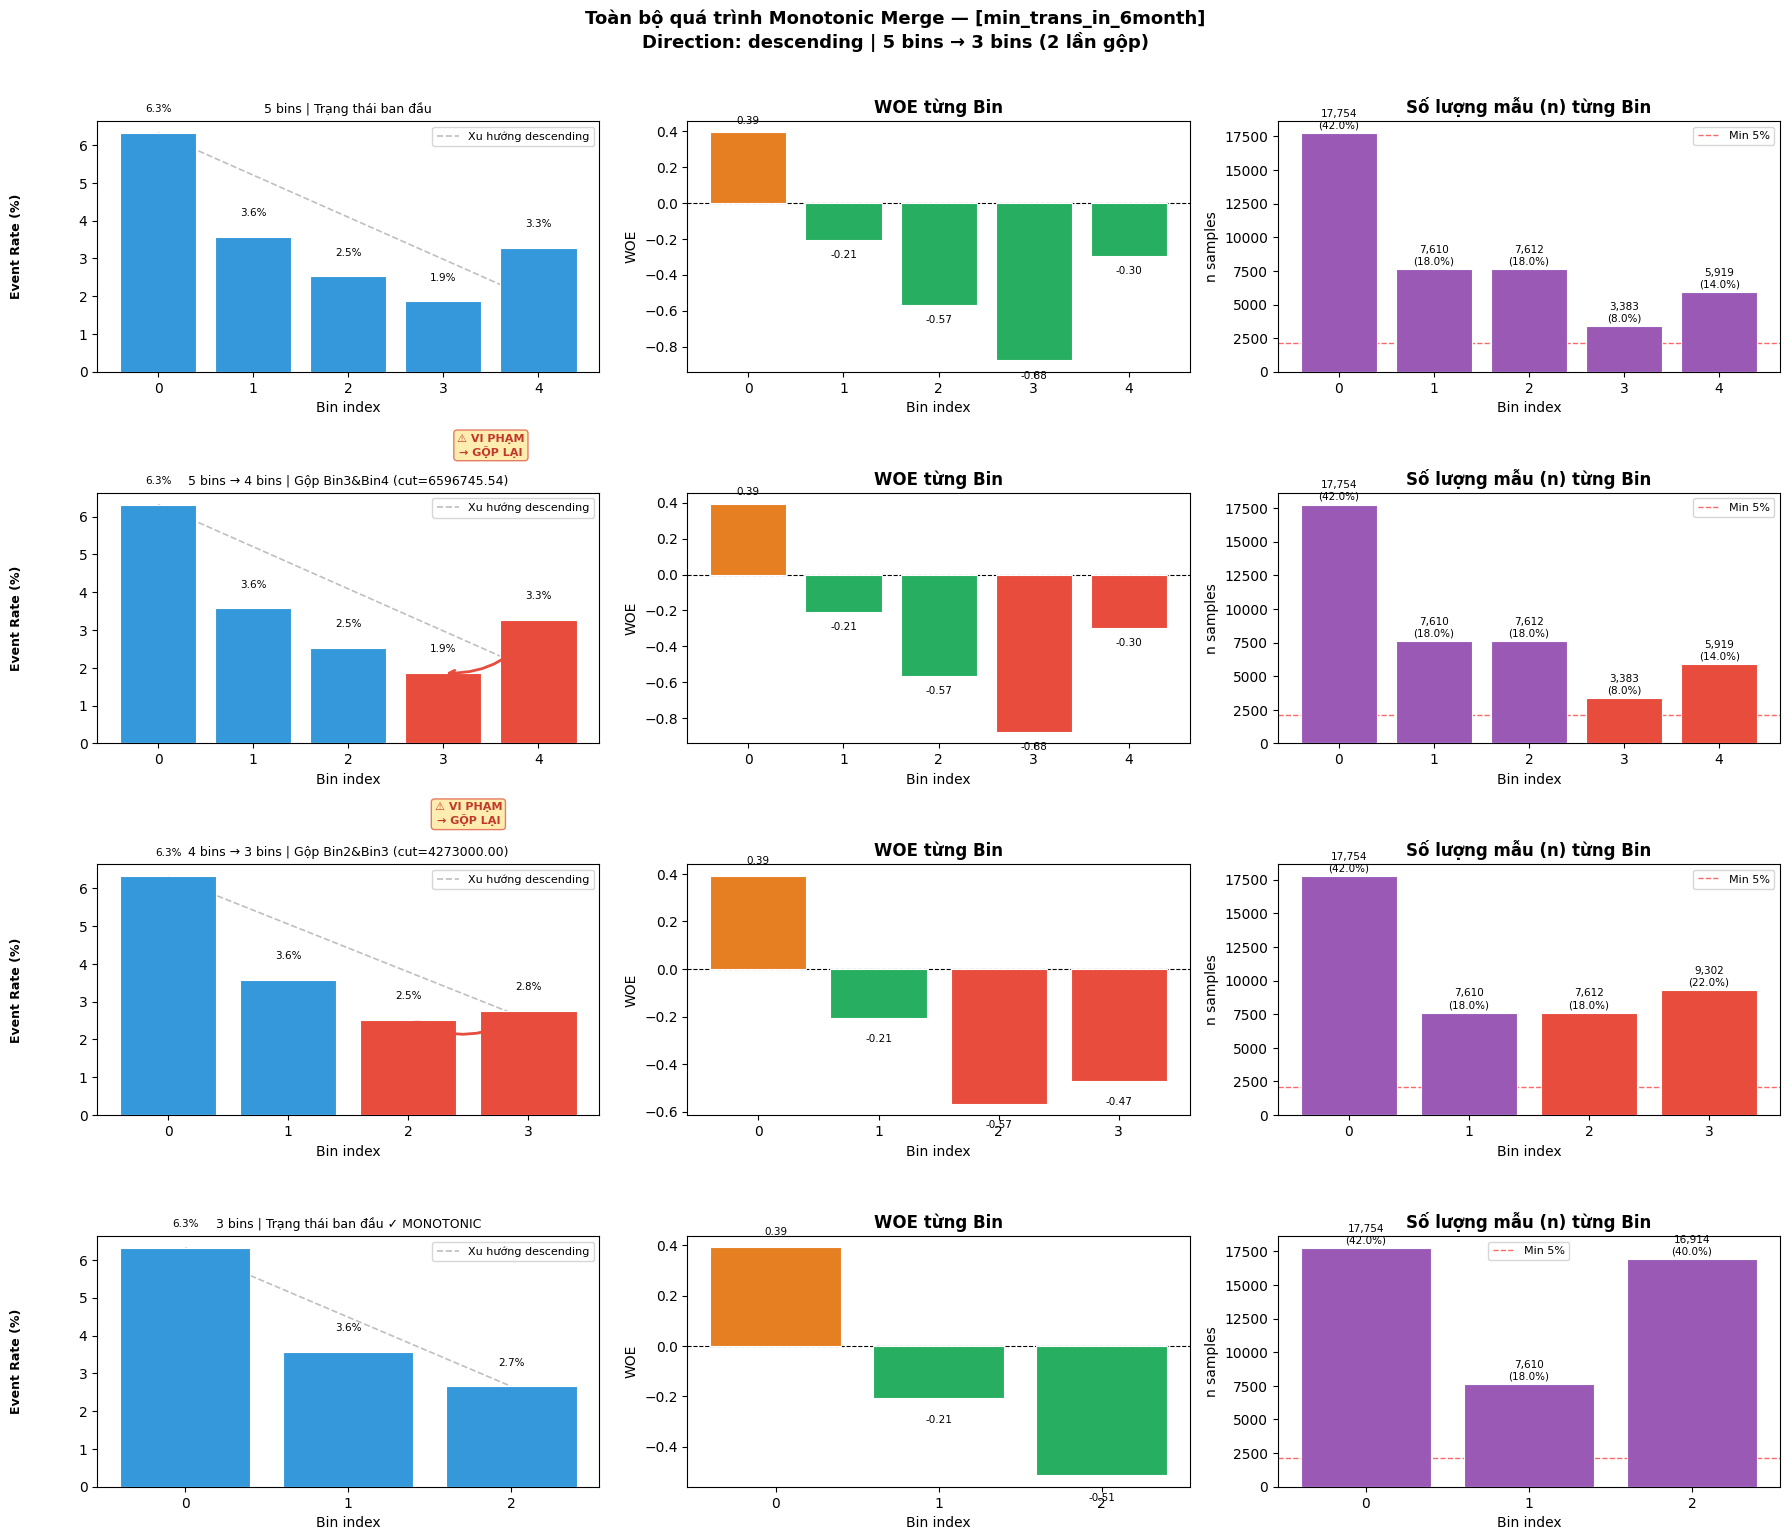

MDLP
               feature                bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month  (-inf, 2.621e+05]    17895     1134       16761   
1  min_trans_in_6month   (2.621e+05, inf]    24383      709       23674   
2  min_trans_in_6month            Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0634  0.3950  0.0793    0.1636  
1      0.0291 -0.4200  0.0843    0.1636  
2      0.0304 -0.3573  0.0060       NaN  


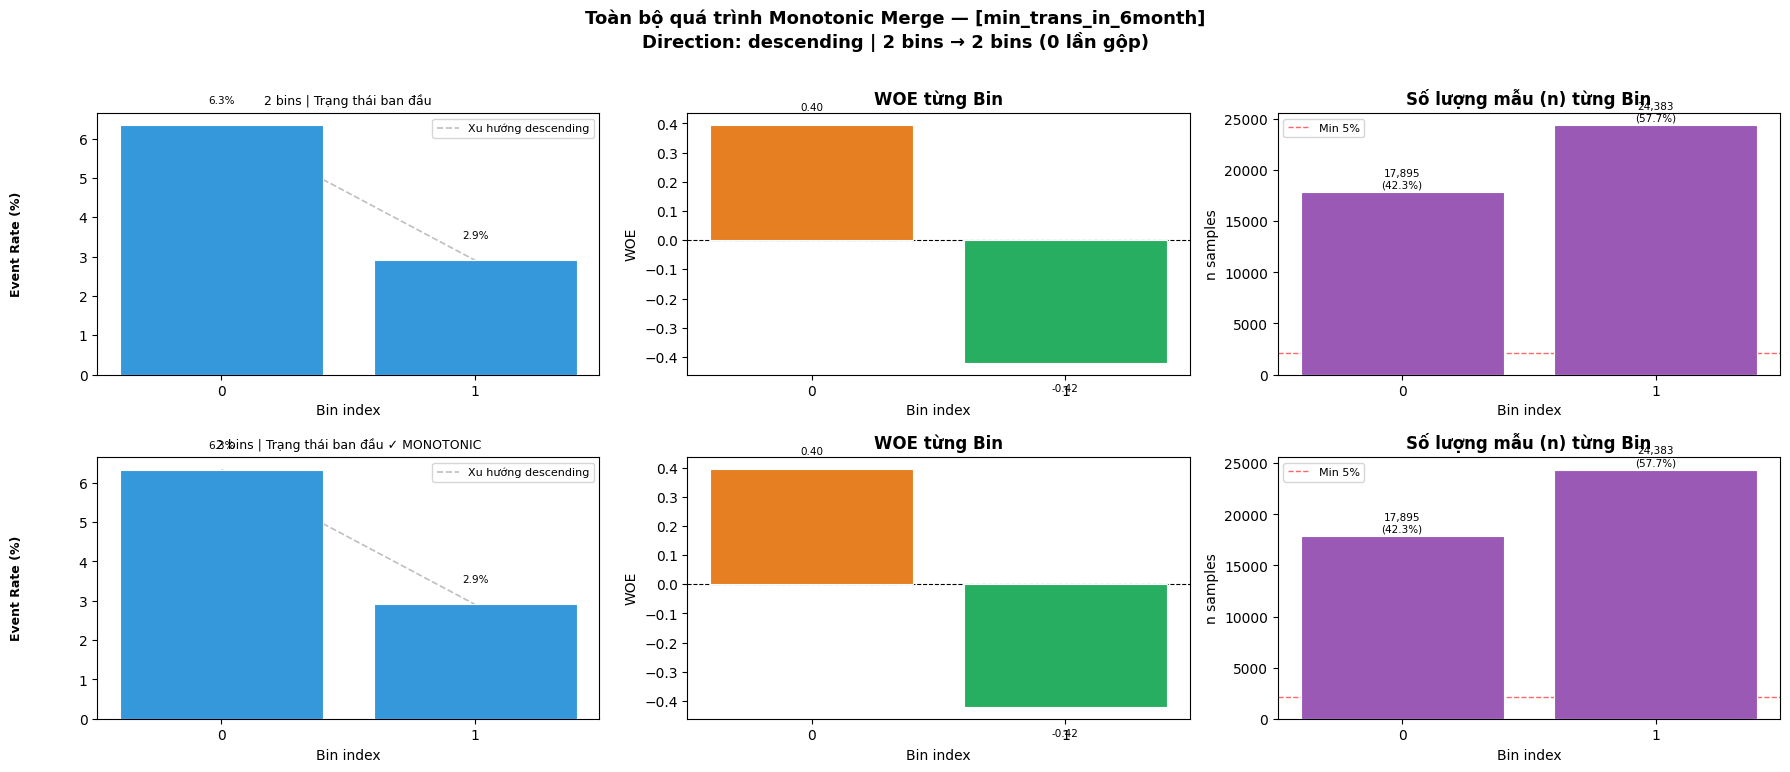

Spearman
               feature                     bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month       (-inf, 6.867e+05]    20291     1220       19071   
1  min_trans_in_6month    (6.867e+05, 8.2e+05]      846       32         814   
2  min_trans_in_6month    (8.2e+05, 1.448e+06]     3384      108        3276   
3  min_trans_in_6month  (1.448e+06, 1.786e+06]     1688       52        1636   
4  min_trans_in_6month        (1.786e+06, inf]    16069      431       15638   
5  min_trans_in_6month                 Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0601  0.3390  0.0645    0.1535  
1      0.0378 -0.1479  0.0004    0.1535  
2      0.0319 -0.3239  0.0073    0.1535  
3      0.0308 -0.3605  0.0044    0.1535  
4      0.0268 -0.5030  0.0769    0.1535  
5      0.0304 -0.3573  0.0060       NaN  


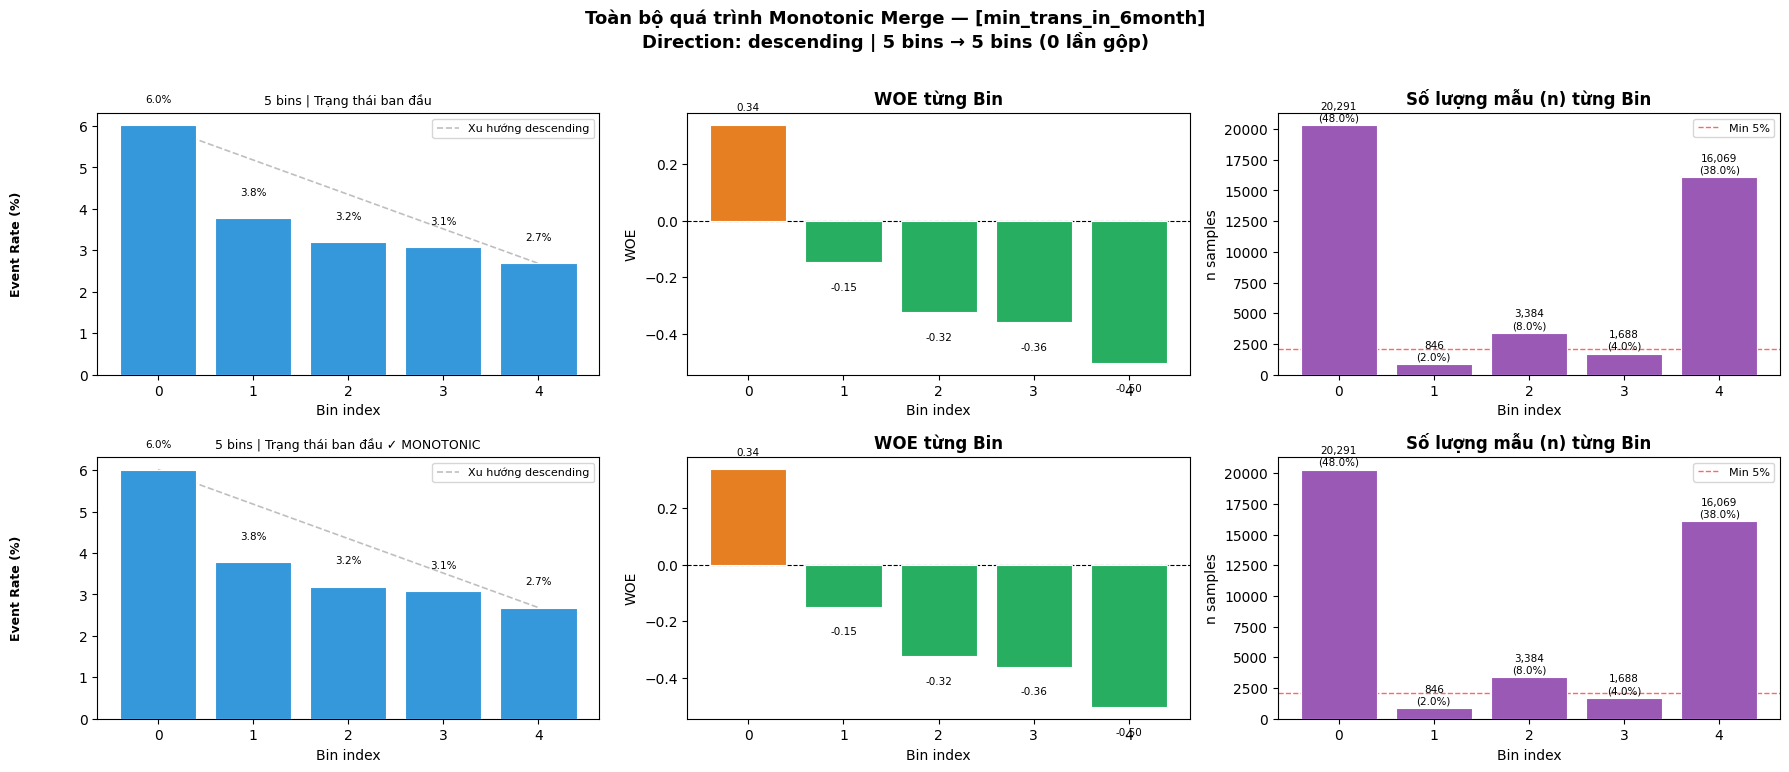

LogOdds
               feature          bin  n_total  n_event  n_nonevent  event_rate  \
0  min_trans_in_6month  (-inf, inf]    42278     1843       40435      0.0436   
1  min_trans_in_6month      Missing     2469       75        2394      0.0304   

      woe  iv_bin  iv_total  
0  0.0000   0.000       0.0  
1 -0.3573   0.006       NaN  


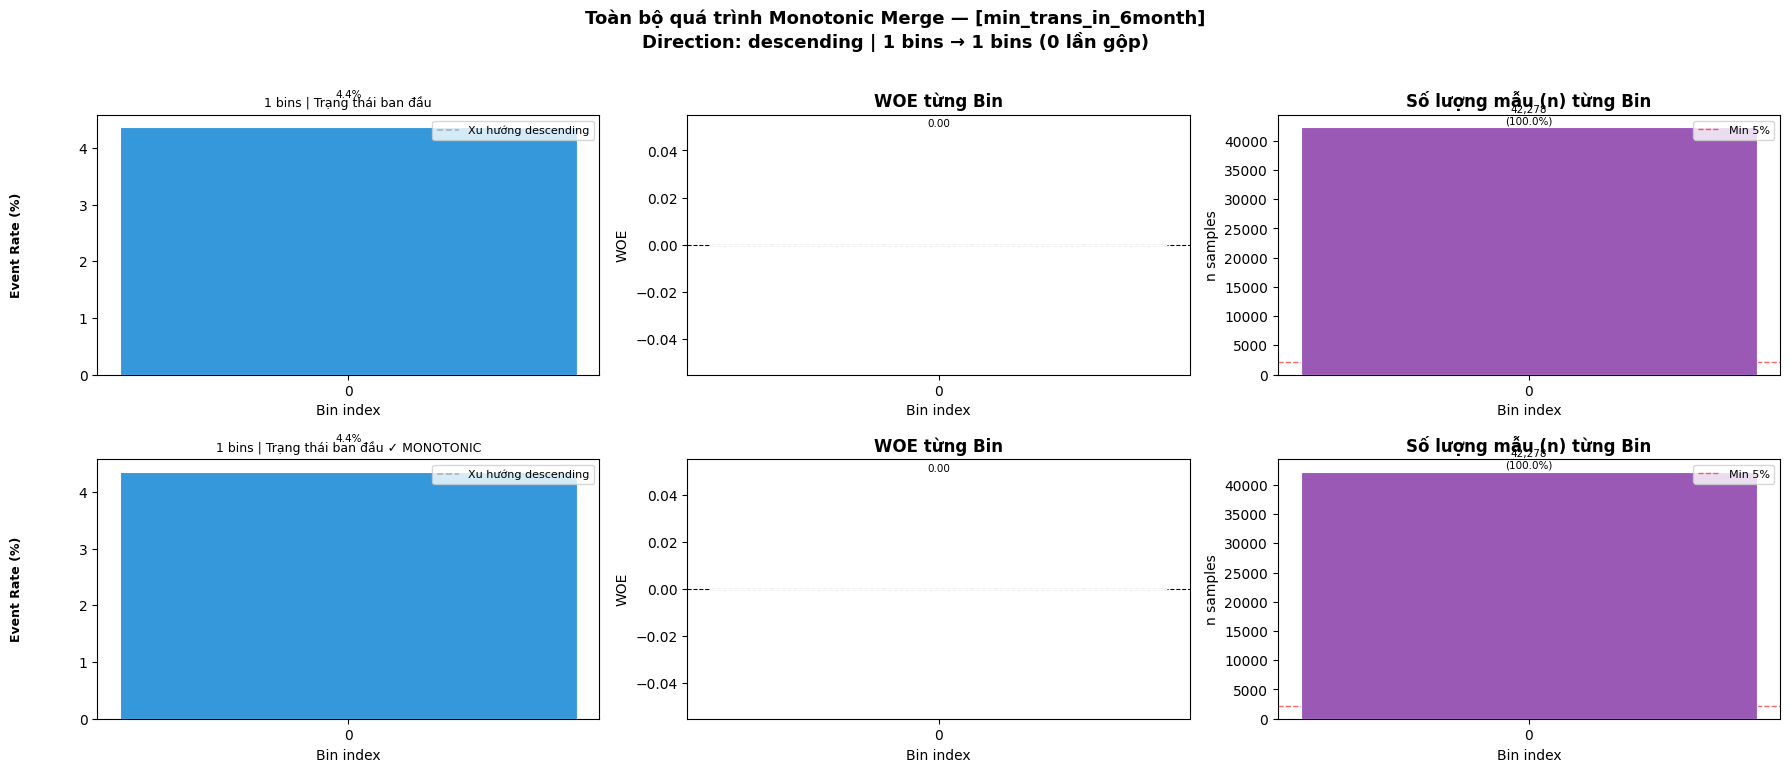

KSOptimal
               feature           bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month  (-inf, 1703]     9523      623        8900   
1  min_trans_in_6month  (1703, 3286]     3171      160        3011   
2  min_trans_in_6month   (3286, inf]    29584     1060       28524   
3  min_trans_in_6month       Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0654  0.4290  0.0506    0.0791  
1      0.0505  0.1534  0.0019    0.0791  
2      0.0358 -0.2042  0.0266    0.0791  
3      0.0304 -0.3573  0.0060       NaN  


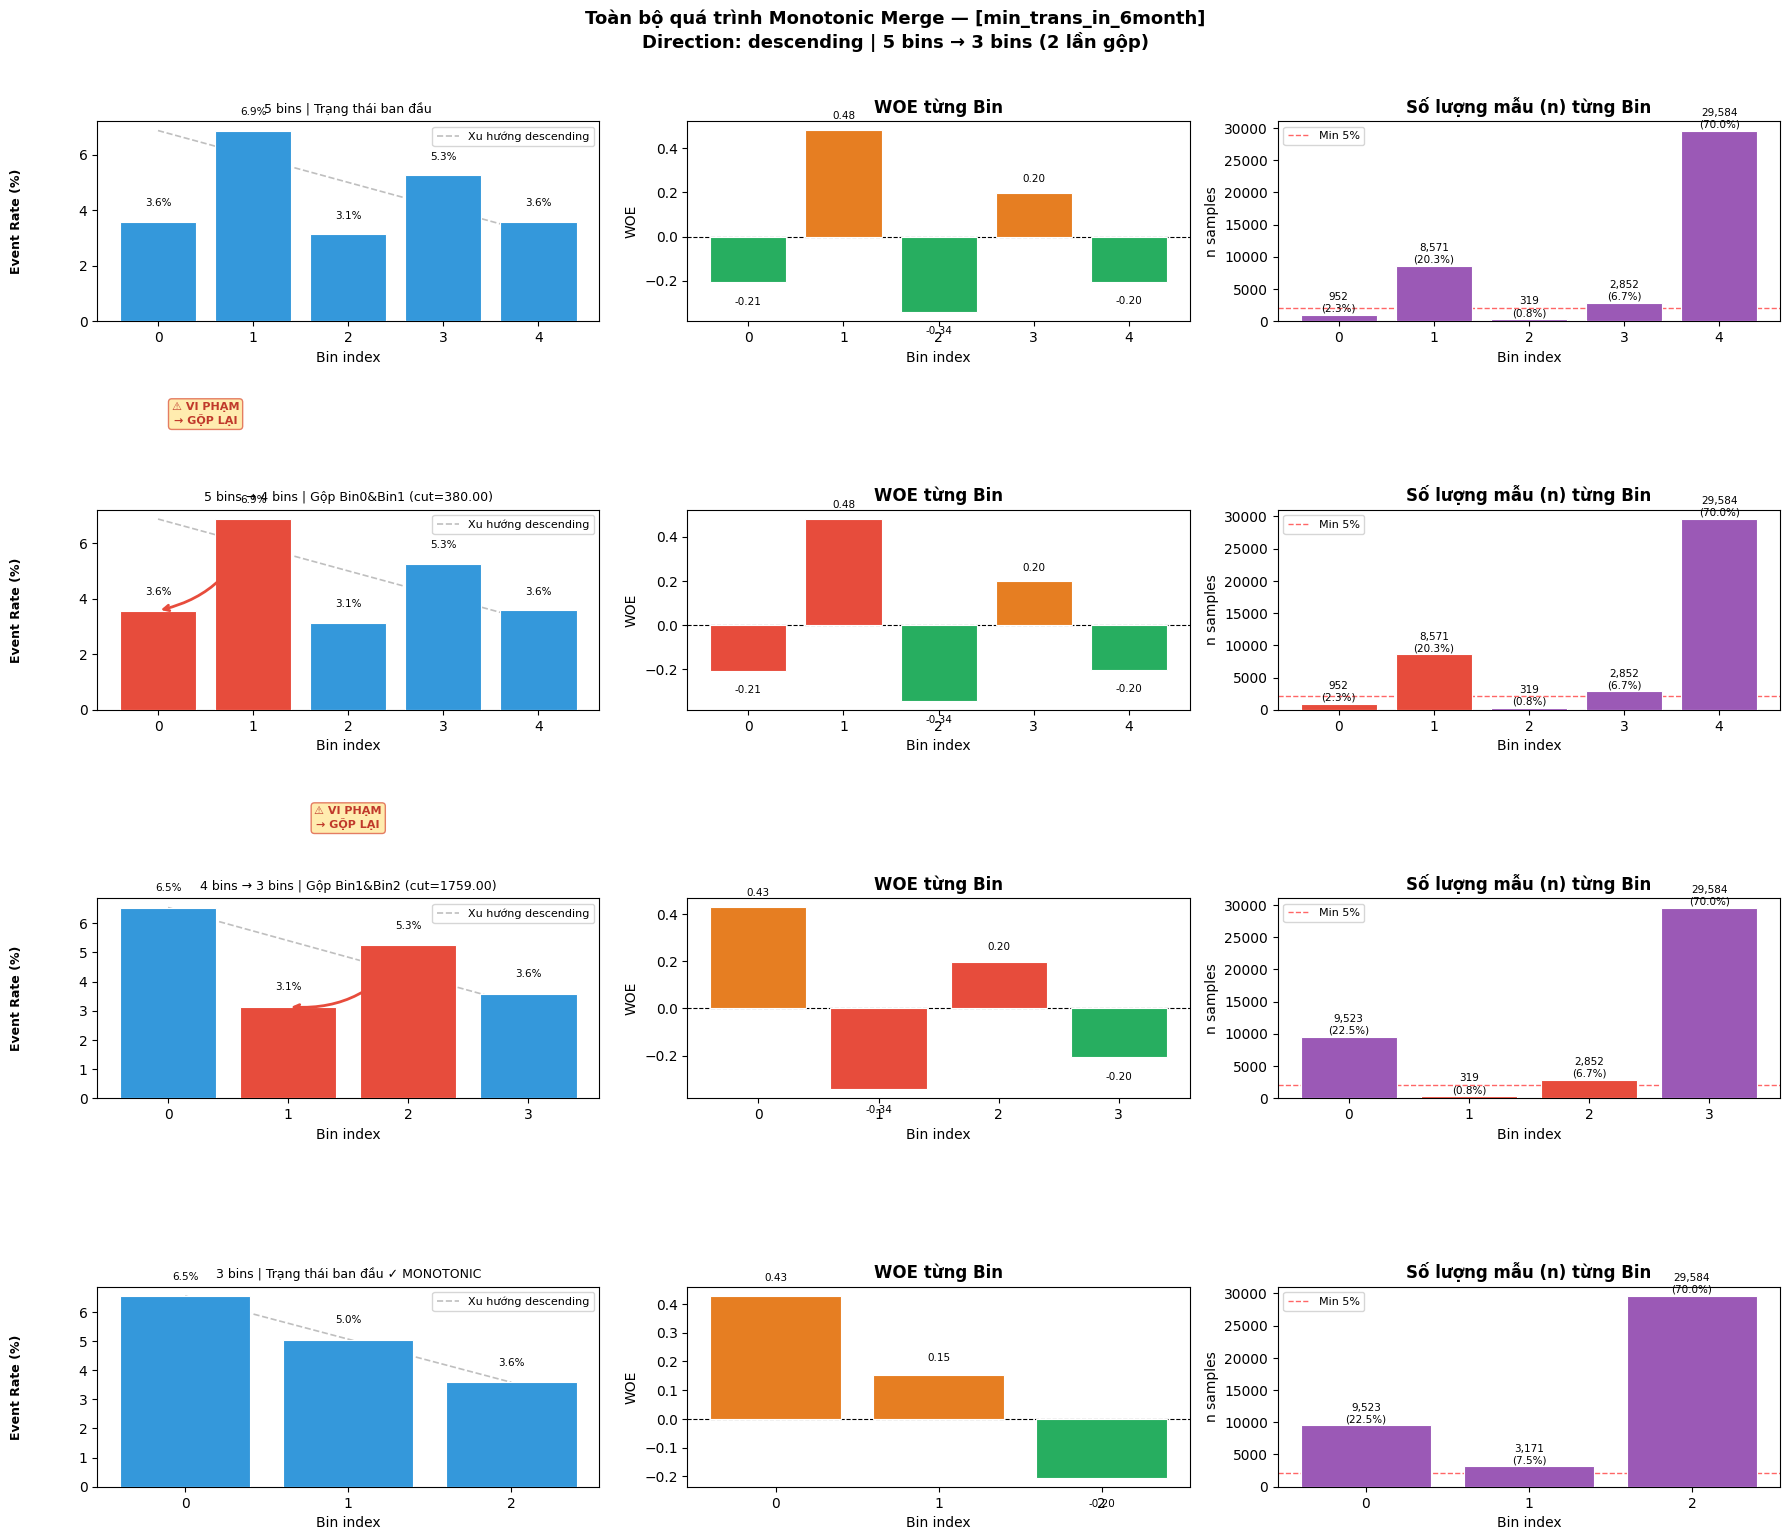

EqualWidth
               feature                     bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month       (-inf, 3.731e+06]    32086     1560       30526   
1  min_trans_in_6month  (3.731e+06, 1.119e+07]     7706      230        7476   
2  min_trans_in_6month        (1.119e+07, inf]     2486       53        2433   
3  min_trans_in_6month                 Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0486  0.1144  0.0105    0.0573  
1      0.0298 -0.3931  0.0236    0.0573  
2      0.0213 -0.7383  0.0232    0.0573  
3      0.0304 -0.3573  0.0060       NaN  


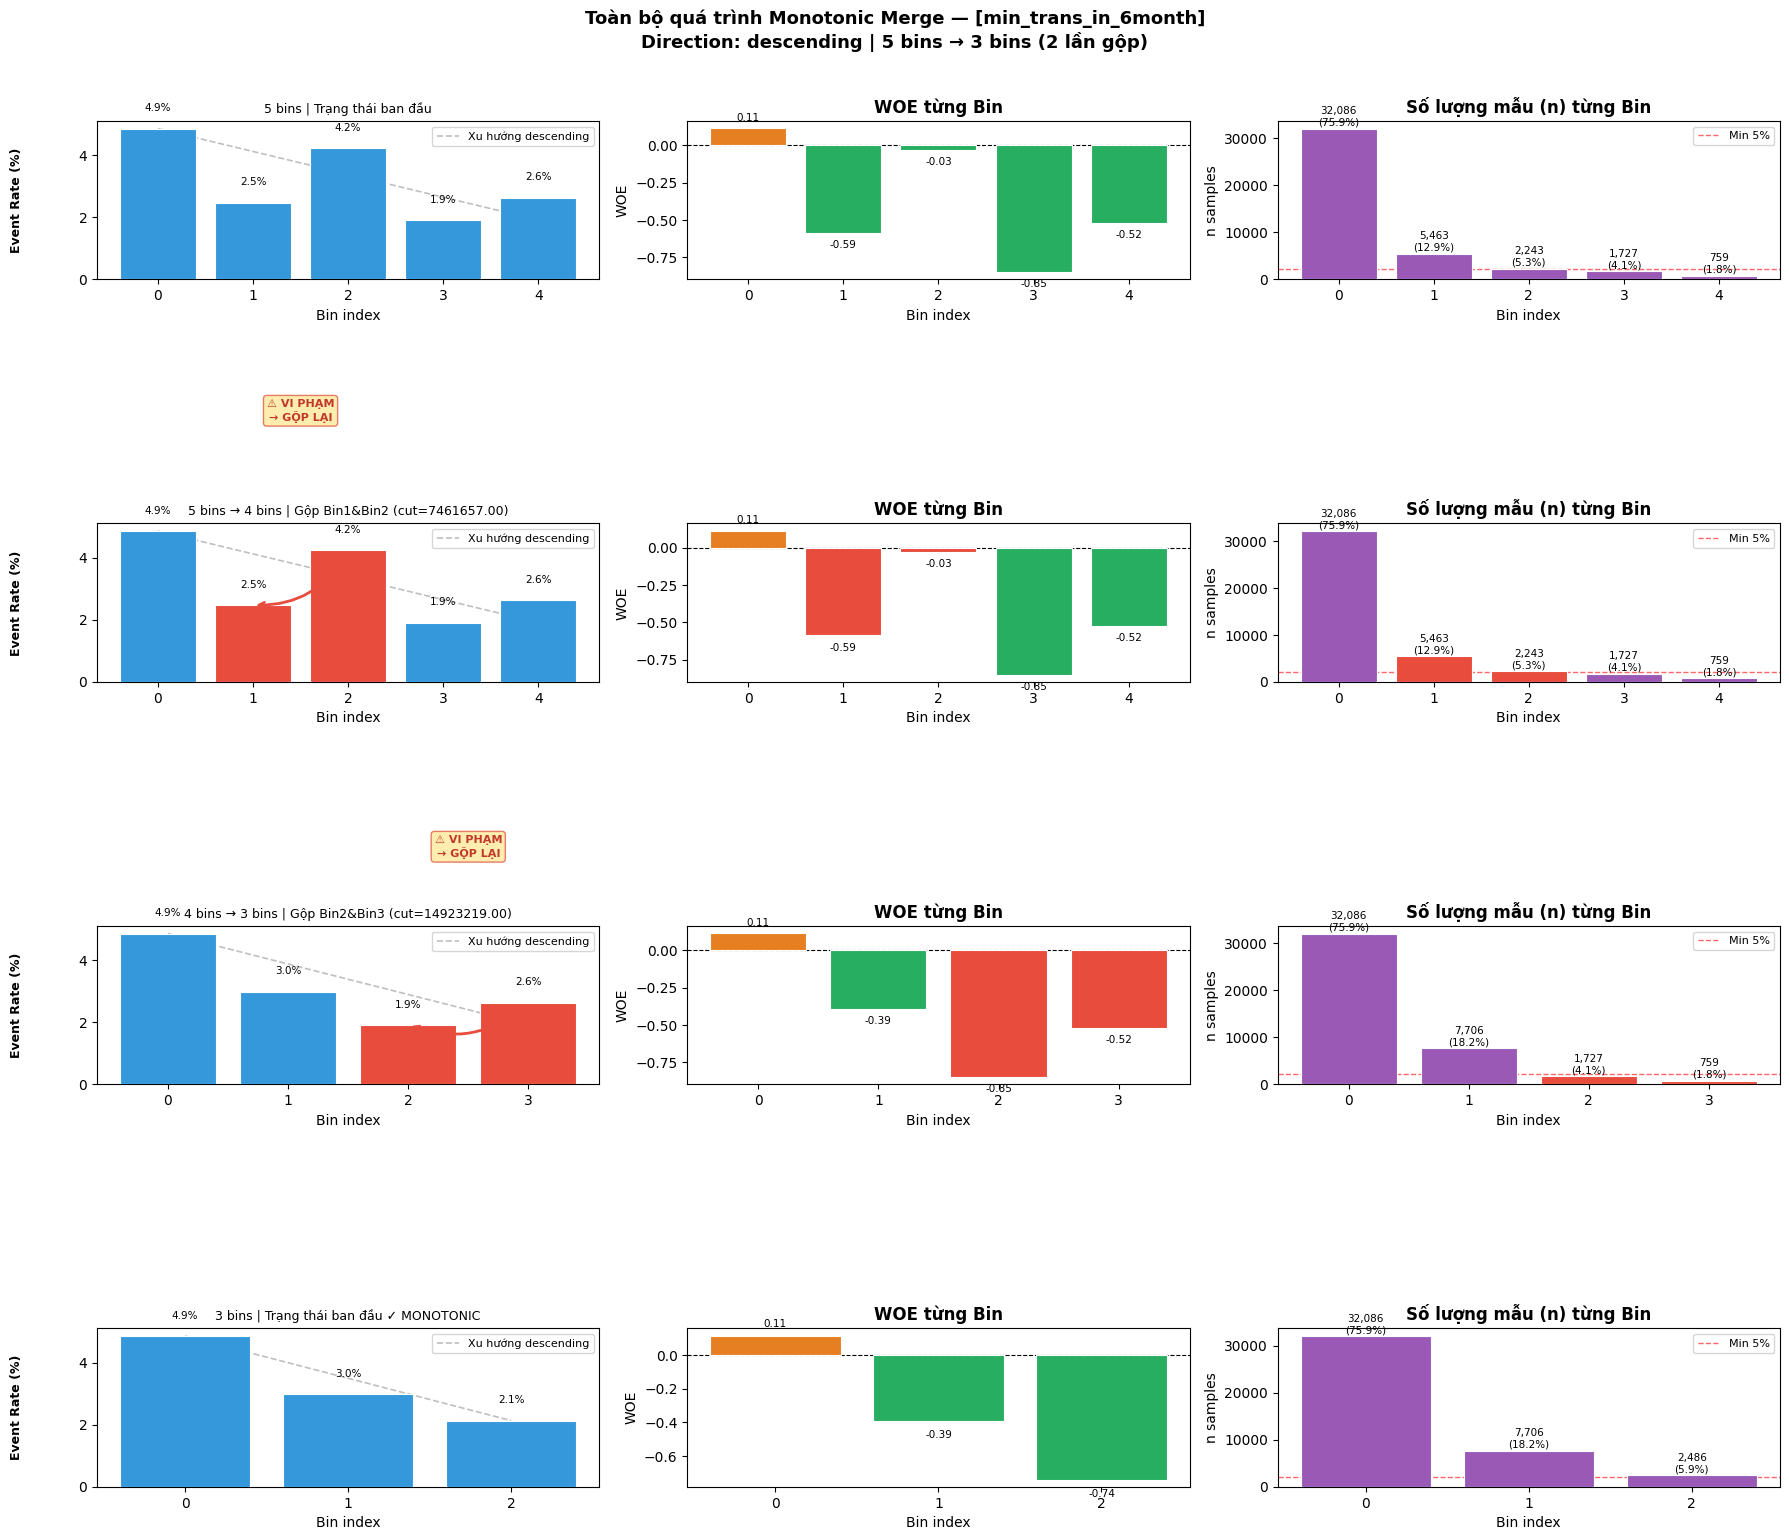

JenksBreaks
               feature                    bin  n_total  n_event  n_nonevent  \
0  min_trans_in_6month      (-inf, 1.651e+06]    25672     1398       24274   
1  min_trans_in_6month  (1.651e+06, 9.55e+06]    13478      367       13111   
2  min_trans_in_6month        (9.55e+06, inf]     3128       78        3050   
3  min_trans_in_6month                Missing     2469       75        2394   

   event_rate     woe  iv_bin  iv_total  
0      0.0545  0.2339  0.0370    0.1171  
1      0.0272 -0.4875  0.0610    0.1171  
2      0.0249 -0.5779  0.0191    0.1171  
3      0.0304 -0.3573  0.0060       NaN  


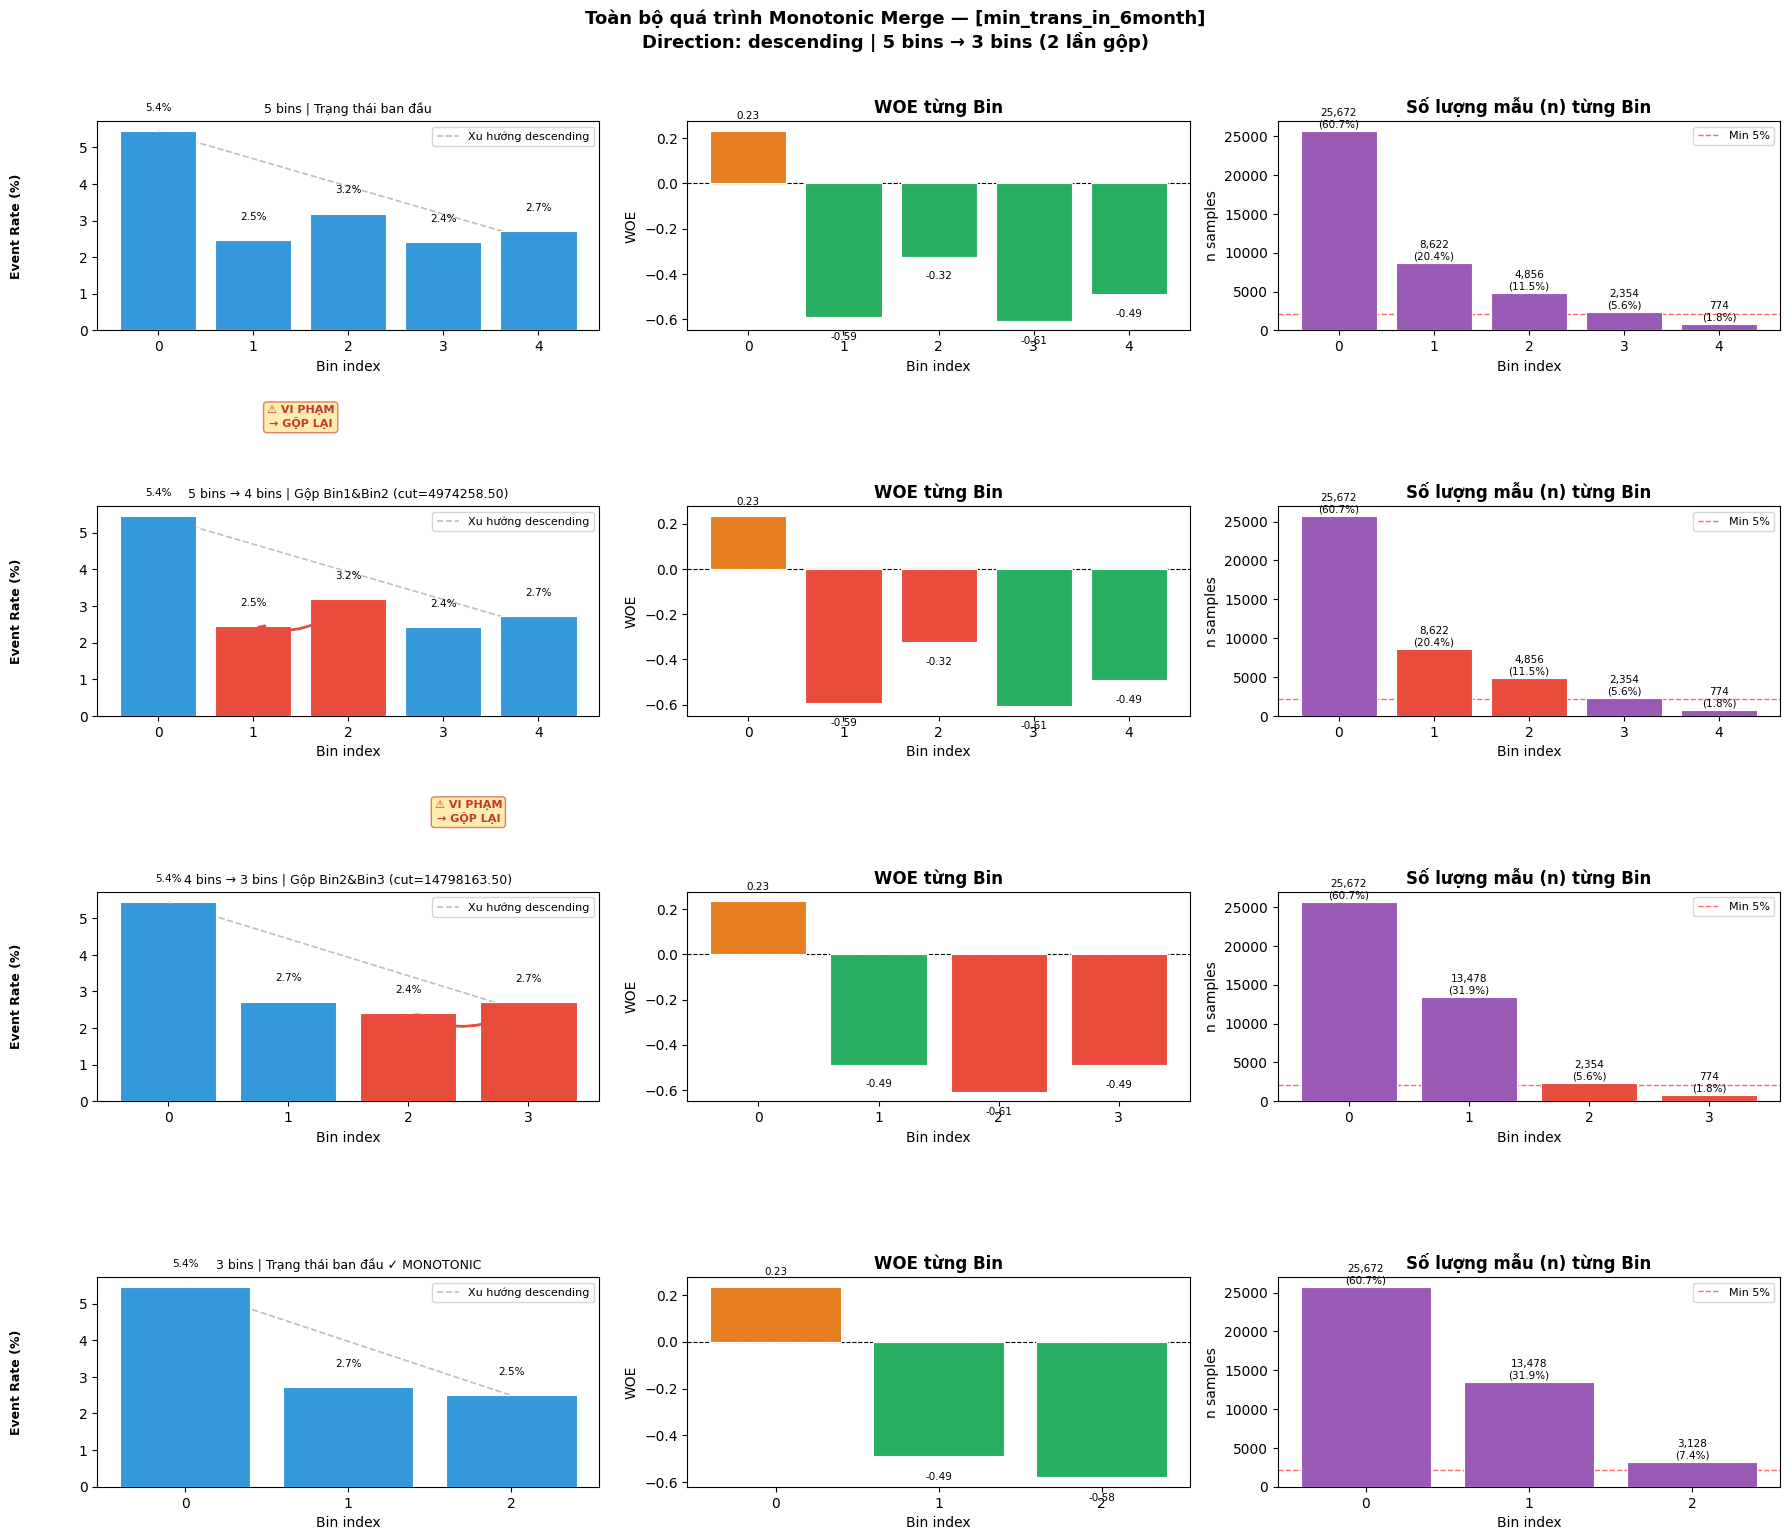

In [12]:
for m in methods:
    print(m)
    print(methods[m].summary())
    _ = methods[m].trace_.plot_steps()
    plt.show()
